# Handwritten Digit Recognition using SVM on MNIST Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

## Loading and Understanding the Dataset

In [2]:
data = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
data.shape

(42000, 785)

## Data Preprocessing and Normalization

In [4]:
X = data.drop("label", axis=1)
y = data["label"]

print(X.shape)
print(y.shape)

(42000, 784)
(42000,)


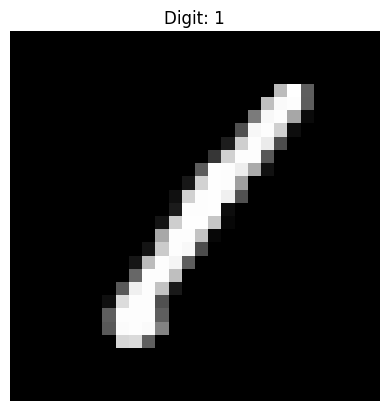

In [5]:
plt.imshow(X.iloc[0].values.reshape(28,28), cmap='gray')
plt.title("Digit: " + str(y.iloc[0]))
plt.axis("off")
plt.show()

In [6]:
print(y.iloc[0])

1


In [7]:
X = X / 255.0

In [8]:
print(X.iloc[0].min(), X.iloc[0].max())

0.0 1.0


## Splitting Dataset into Training and Validation Sets

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape
X_test.shape

(8400, 784)

## Dimensionality Reduction using PCA

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

## Training the SVM Classifier

In [11]:
model = SVC(kernel='rbf', C=5, gamma='scale')

model.fit(X_train, y_train)

SVC(C=5)

## Generating Predictions

In [12]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9820238095238095


In [13]:
test_data = pd.read_csv('/kaggle/input/competitions/digit-recognizer/test.csv')

print(test_data.shape)
test_data.head()

(28000, 784)


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
test_data = test_data / 255.0

## Generating Predictions for Kaggle Submission

In [15]:
test_data = pca.transform(test_data)

predictions = model.predict(test_data)

## Creating the Submission File

In [16]:
submission = pd.DataFrame({
    "ImageId": range(1, len(predictions) + 1),
    "Label": predictions
})

submission.to_csv("submission.csv", index=False)

submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3
